### 1. Import Libraries

In [5]:
import os
import zipfile
import shutil
import random
import numpy as np
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, ResNet50, VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt

### 2. Extract the dataset

In [10]:
# Unzip the dataset if not already unzipped
zip_path = '/content/Face_mask_detection.zip'
extract_path = '/content/face_mask_data'

if not os.path.exists(extract_path):
    os.makedirs(extract_path)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f'Dataset extracted to {extract_path}')
else:
    print(f'Dataset already extracted to {extract_path}')

Dataset extracted to /content/face_mask_data


### 3. Split the Dataset

In [11]:
random.seed(42)

source_dir = "/content/face_mask_data/data"
output_dir = "/content/face_mask_data"

train_dir = os.path.join(output_dir, "train")
test_dir = os.path.join(output_dir, "test")

classes = ["with_mask", "without_mask", "incorrect_mask"]

for folder in [train_dir, test_dir]:
    os.makedirs(folder, exist_ok=True)

for cls in classes:

    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    images = os.listdir(os.path.join(source_dir, cls))
    random.shuffle(images)

    split = int(len(images)*0.8)

    train_images = images[:split]
    test_images = images[split:]

    for img in train_images:
        shutil.copy(
            os.path.join(source_dir, cls, img),
            os.path.join(train_dir, cls, img)
        )

    for img in test_images:
        shutil.copy(
            os.path.join(source_dir, cls, img),
            os.path.join(test_dir, cls, img)
        )

print("Dataset successfully split.")

Dataset successfully split.


### 4. Data Loading with `ImageDataGenerator` - Used for both models

In [12]:
IMG_SIZE = (128,128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    "/content/face_mask_data/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

validation_generator = train_datagen.flow_from_directory(
    "/content/face_mask_data/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

test_generator = test_datagen.flow_from_directory(
    "/content/face_mask_data/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 5284 images belonging to 3 classes.
Found 1320 images belonging to 3 classes.
Found 1652 images belonging to 3 classes.


### 5. Callbacks - Used for both models

In [13]:
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

### 6. Model 1 - EfficientNetB0

In [14]:
base_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_eff.trainable = False

x = GlobalAveragePooling2D()(base_eff.output)
x = Dropout(0.2)(x)
out = Dense(3, activation='softmax')(x)

model_eff = Model(inputs=base_eff.input, outputs=out)

model_eff.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
history_eff = model_eff.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=25,
    callbacks=[reduce_lr, early_stop]
)

Epoch 1/25
 13/166 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.5052 - loss: 1.0169

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


166/166 ━━━━━━━━━━━━━━━━━━━━ 84s 324ms/step - accuracy: 0.4652 - loss: 0.9476 - val_accuracy: 0.4636 - val_loss: 0.9313 - learning_rate: 0.0010
Epoch 2/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 17s 101ms/step - accuracy: 0.4516 - loss: 0.9441 - val_accuracy: 0.4515 - val_loss: 0.9685 - learning_rate: 0.0010
Epoch 3/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 16s 94ms/step - accuracy: 0.4635 - loss: 0.9352 - val_accuracy: 0.4636 - val_loss: 0.9482 - learning_rate: 0.0010
Epoch 4/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 16s 95ms/step - accuracy: 0.4654 - loss: 0.9322 - val_accuracy: 0.4629 - val_loss: 0.9276 - learning_rate: 0.0010
Epoch 5/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - accuracy: 0.4502 - loss: 0.9402 - val_accuracy: 0.4614 - val_loss: 0.9255 - learning_rate: 0.0010
Epoch 6/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - accuracy: 0.4608 - loss: 0.9361 - val_accuracy: 0.4636 - val_loss: 0.9392 - learning_rate: 0.0010
Epoch 7/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - accuracy: 0.4635 - loss: 0.93

### 7. Model 2 - ResNet50

In [16]:
base_res = ResNet50(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_res.trainable = False

x = GlobalAveragePooling2D()(base_res.output)
x = Dropout(0.5)(x)
out = Dense(3, activation='softmax')(x)

model_resnet = Model(inputs=base_res.input, outputs=out)

model_resnet.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [17]:
history_resnet = model_resnet.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=25,
    callbacks=[reduce_lr, early_stop]
)

Epoch 1/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 41s 169ms/step - accuracy: 0.4977 - loss: 0.9667 - val_accuracy: 0.4712 - val_loss: 0.9273 - learning_rate: 0.0010
Epoch 2/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 17s 103ms/step - accuracy: 0.5558 - loss: 0.8892 - val_accuracy: 0.4553 - val_loss: 0.9215 - learning_rate: 0.0010
Epoch 3/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 17s 100ms/step - accuracy: 0.5611 - loss: 0.8830 - val_accuracy: 0.5068 - val_loss: 0.9220 - learning_rate: 0.0010
Epoch 4/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - accuracy: 0.5799 - loss: 0.8734 - val_accuracy: 0.4591 - val_loss: 0.9103 - learning_rate: 0.0010
Epoch 5/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 17s 102ms/step - accuracy: 0.5831 - loss: 0.8661 - val_accuracy: 0.5152 - val_loss: 0.9095 - learning_rate: 0.0010
Epoch 6/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 17s 100ms/step - accuracy: 0.5838 - loss: 0.8579 - val_accuracy: 0.4932 - val_loss: 0.9000 - learning_rate: 0.0010
Epoch 7/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 16s 99ms/step - accuracy: 0.587

### 8. Model 3 - VGG16

In [18]:
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_vgg.trainable = False

x = GlobalAveragePooling2D()(base_vgg.output)
x = Dropout(0.5)(x)
out = Dense(3, activation='softmax')(x)

model_vgg = Model(inputs=base_vgg.input, outputs=out)

model_vgg.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
history_vgg = model_vgg.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=25,
    callbacks=[reduce_lr, early_stop]
)

Epoch 1/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 35s 153ms/step - accuracy: 0.6393 - loss: 0.8282 - val_accuracy: 0.7606 - val_loss: 0.6192 - learning_rate: 0.0010
Epoch 2/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 17s 104ms/step - accuracy: 0.7943 - loss: 0.5550 - val_accuracy: 0.8106 - val_loss: 0.4844 - learning_rate: 0.0010
Epoch 3/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 18s 107ms/step - accuracy: 0.8223 - loss: 0.4723 - val_accuracy: 0.8341 - val_loss: 0.4325 - learning_rate: 0.0010
Epoch 4/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 17s 105ms/step - accuracy: 0.8378 - loss: 0.4364 - val_accuracy: 0.8515 - val_loss: 0.3895 - learning_rate: 0.0010
Epoch 5/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 18s 106ms/step - accuracy: 0.8503 - loss: 0.4079 - val_accuracy: 0.8758 - val_loss: 0.3622 - learning_rate: 0.0010
Epoch 6/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 18s 107ms/step - accuracy: 0.8490 - loss: 0.3941 - val_accuracy: 0.8742 - val_loss: 0.3440 - learning_rate: 0.0010
Epoch 7/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 17s 105ms/step - accuracy: 0.8

### 9. Plot Training Curves

#### Plot Accuracy - EfficientNetB0

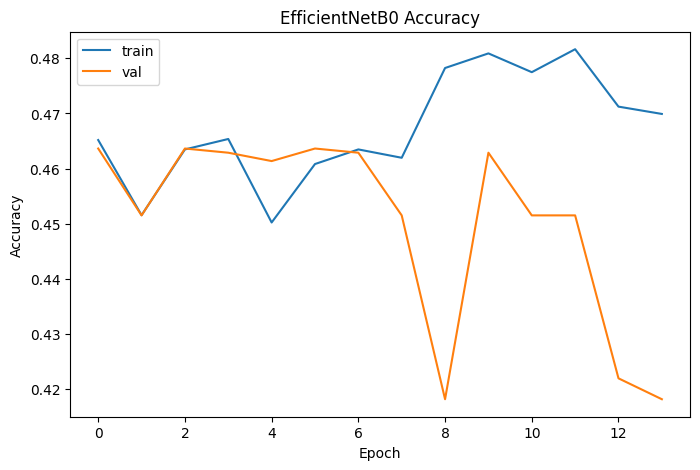

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history_eff.history['accuracy'], label='train')
plt.plot(history_eff.history['val_accuracy'], label='val')
plt.title("EfficientNetB0 Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#### Plot Loss - EfficientNetB0

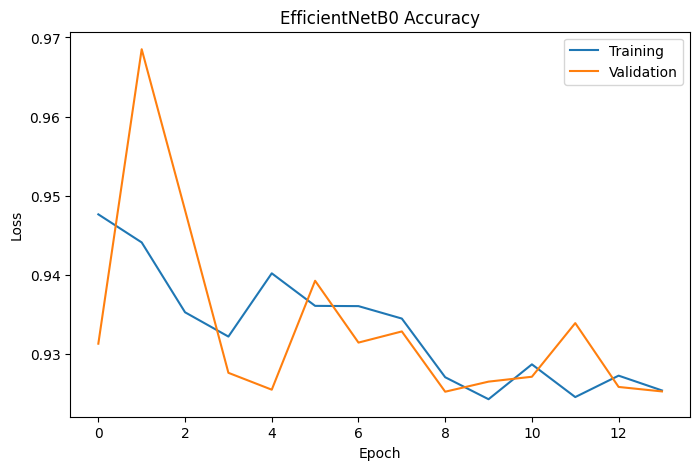

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history_eff.history['loss'],label='Training')
plt.plot(history_eff.history['val_loss'],label='Validation')
plt.title("EfficientNetB0 Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

#### Plot Accuracy - ResNet50

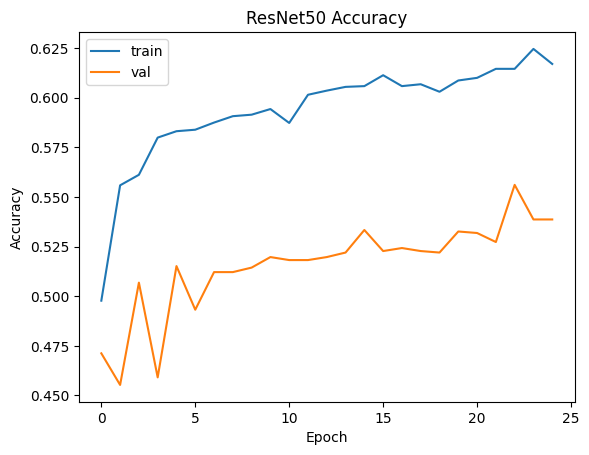

In [22]:
plt.plot(history_resnet.history['accuracy'], label='train')
plt.plot(history_resnet.history['val_accuracy'], label='val')
plt.title("ResNet50 Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#### Plot Loss - ResNet50

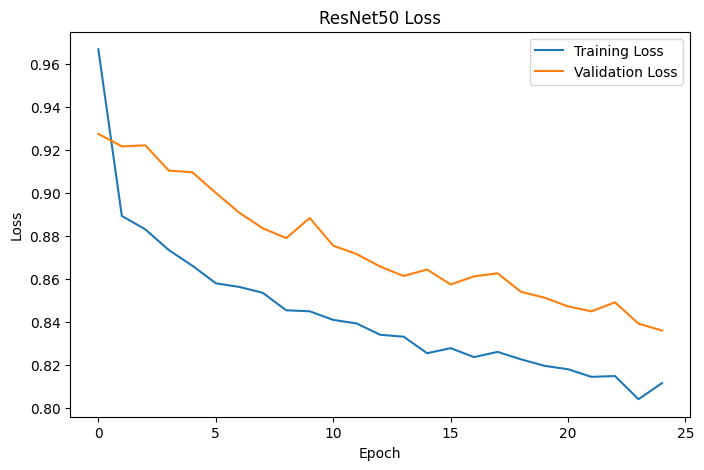

In [23]:
plt.figure(figsize=(8,5))

plt.plot(history_resnet.history['loss'],label='Training Loss')
plt.plot(history_resnet.history['val_loss'],label='Validation Loss')
plt.title("ResNet50 Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

#### Plot Accuracy - VGG16

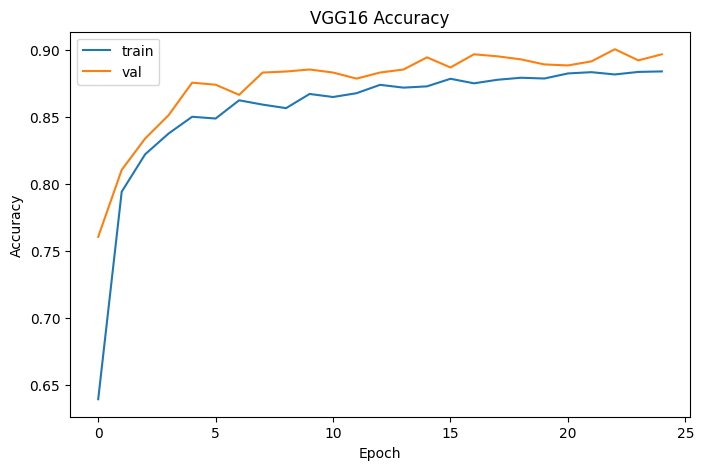

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history_vgg.history['accuracy'], label='train')
plt.plot(history_vgg.history['val_accuracy'], label='val')
plt.title("VGG16 Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#### Plot Loss - VGG16

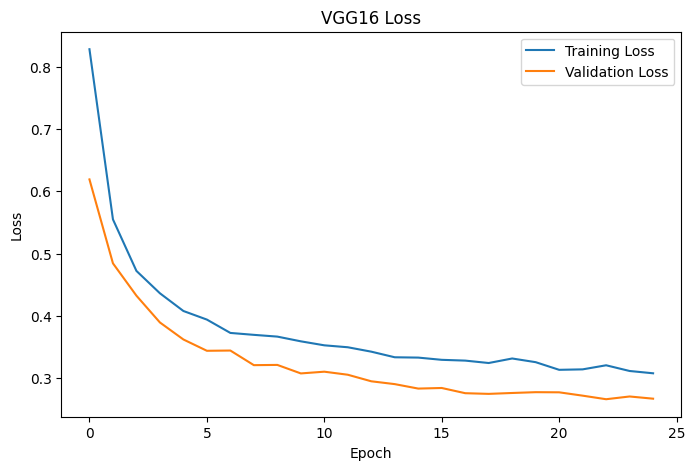

In [25]:
plt.figure(figsize=(8,5))

plt.plot(history_vgg.history['loss'],label='Training Loss')
plt.plot(history_vgg.history['val_loss'],label='Validation Loss')
plt.title("VGG16 Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### 10. Evaluation (All Models)

In [26]:
eff_loss, eff_acc = model_eff.evaluate(test_generator)
res_loss, res_acc = model_resnet.evaluate(test_generator)
vgg_loss, vgg_acc = model_vgg.evaluate(test_generator)

print("EfficientNetB0 Accuracy:", eff_acc)
print("ResNet50 Accuracy:", res_acc)
print("VGG16 Accuracy:", vgg_acc)

52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 287ms/step - accuracy: 0.5091 - loss: 0.9212
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - accuracy: 0.6029 - loss: 0.8040
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 186ms/step - accuracy: 0.9189 - loss: 0.2463
EfficientNetB0 Accuracy: 0.5090798735618591
ResNet50 Accuracy: 0.6029055714607239
VGG16 Accuracy: 0.9188861846923828


### 19. Select the Best Model

In [27]:
results = [
    ("VGG16", vgg_acc, model_vgg),
    ("EfficientNetB0", eff_acc, model_eff),
    ("ResNet50", res_acc, model_resnet)
]

best_model_name, best_acc, best_model = max(results, key=lambda x: x[1])

print(f"Best Model: {best_model_name}")
print(f"Accuracy: {best_acc:.4f}")

Best Model: VGG16
Accuracy: 0.9189


### 20. Predict with the Best Model

In [28]:
predictions = best_model.predict(test_generator)

predicted_classes = np.argmax(predictions, axis=1)

52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step


#### Get True Labels + Class Names

In [29]:
true_classes = test_generator.classes
class_names = list(test_generator.class_indices.keys())

#### Plot 10 Random Test Images (True vs Predicted)

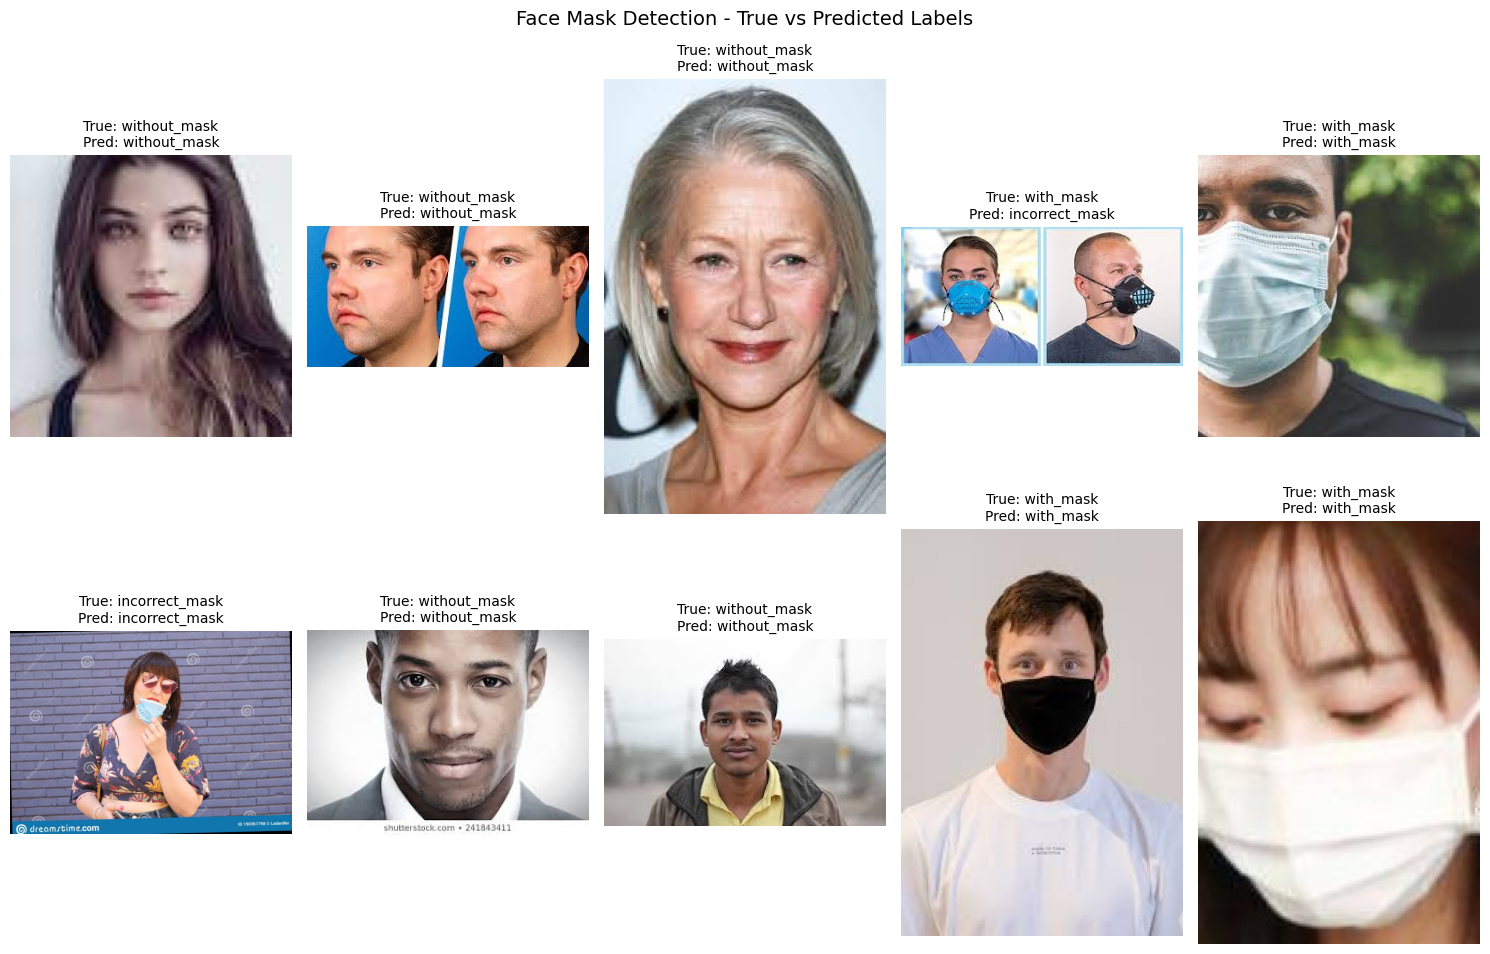

Test Accuracy: 0.9188861985472155


In [30]:
file_paths = test_generator.filepaths

# pick 10 random samples
indices = random.sample(range(len(file_paths)), 10)

plt.figure(figsize=(15, 10))

for i, idx in enumerate(indices):

    img = plt.imread(file_paths[idx])

    true_label = class_names[true_classes[idx]]
    pred_label = class_names[predicted_classes[idx]]

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")

    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=10, color="black")
    plt.suptitle("Face Mask Detection - True vs Predicted Labels", fontsize=14)

plt.tight_layout()
plt.show()

print("Test Accuracy:", accuracy_score(true_classes, predicted_classes))